In [1]:
import torch

In [2]:
### Select device (GPU)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
print('Selected device:', device)

Selected device: cuda


In [3]:
with open('../data-sets/tiny_shakespeare.txt', 'r', encoding='utf-8') as f:
    text = f.read()

dataset = text

import random
print('Random line:', random.choice(dataset.split('\n')))
print('Size of dataset:', len(dataset.split('\n')), 'lines')

Random line: And we may soon our satisfaction have
Size of dataset: 40001 lines


In [4]:
unique_chars = sorted(set(dataset))

print(unique_chars)

char_to_num = {char: num for num, char in enumerate(unique_chars)}
num_to_char = {num: char for char, num in char_to_num.items()}

vocab_size = len(unique_chars) # Vocabulary size |V|
print('Number of unique chars:', vocab_size)

['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Number of unique chars: 65


In [5]:
import torch
import torch.nn.functional as F

### Create data set ###

train_frac = 0.95
seq_length = 75

def build_dataset(data):
    X, Y = [], []
    
    context = [0] * seq_length
    
    for ch in data:
        X.append(context)
        ix = char_to_num[ch]
        context = context[1:] + [ix]
        Y.append(context)

    X = torch.tensor(X)
    Y = torch.tensor(Y)

    return X, Y

split = int(train_frac * len(dataset))

Xtr, Ytr = build_dataset(dataset[:split])
Xte, Yte = build_dataset(dataset[split:])

print('Example shape:', Xtr[0].shape, '=>', Ytr[0].shape)
print('Amount of train examples:', len(Xtr))

Example shape: torch.Size([75]) => torch.Size([75])
Amount of train examples: 1059624


In [6]:
import torch.nn as nn

emb_dim = 60
hidden_size = 128
num_layers = 3

class RNN(nn.Module):
    def __init__(self, hidden_size, num_layers=1):
        super(RNN, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embeddings = nn.Embedding(vocab_size, emb_dim)
        self.rnn        = nn.RNN(emb_dim, hidden_size, num_layers, batch_first=True)
        self.fc         = nn.Linear(hidden_size, vocab_size)

    def forward(self, input, hidden):    
        embs = self.embeddings(input) # (B x Seq len x emb dim)

        output, hidden = self.rnn(embs, hidden)
        output = self.fc(output)

        if input.dim() == 2:
            output = output.permute(0, 2, 1)
        
        return output, hidden

    def init_hidden(self, batch_size=None):
        if batch_size is None:
            return torch.zeros(self.num_layers, self.hidden_size).to(device)
        else:
            return torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)



model = RNN(hidden_size).to(device)

print('Total parameters:', sum(p.numel() for p in model.parameters()))

Total parameters: 36605


In [7]:
lr = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [8]:
import torch.nn.functional as F

### Train model ###
epochs = 50000
batch_size = 64
eval_batch_size = 9600

epoch_count       = []
train_loss_values = []
test_loss_values  = []

from tqdm import trange
for epoch in trange(epochs):
    
    # Sample mini-batch and send to gpu
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix].to(device), Ytr[ix].to(device)

    hidden = model.init_hidden(batch_size) # Initialize hidden state
    output, _ = model(Xb, hidden)          # Do the forward pass
    loss = criterion(output, Yb)           # Calculate the loss
    optimizer.zero_grad()                  # Reset parameters
    loss.backward()                        # Backpropagation
    optimizer.step()                       # Update parameters

    # Report progression every so often
    if ((epoch + 1) % (epochs / 50) == 0):
        
        # Sample larger train-batch
        ix = torch.randint(0, Xtr.shape[0], (eval_batch_size,))
        Xb, Yb = Xtr[ix].to(device), Ytr[ix].to(device)
        
        hidden = model.init_hidden(eval_batch_size)
        with torch.inference_mode():
            output, _ = model(Xb, hidden)
            loss = F.cross_entropy(output, Yb)

        # Sample larger test-batch
        ix = torch.randint(0, Xte.shape[0], (eval_batch_size,))
        Xb, Yb = Xte[ix].to(device), Yte[ix].to(device)

        hidden = model.init_hidden(eval_batch_size)
        with torch.inference_mode():
            output, _ = model(Xb, hidden)
            test_loss = F.cross_entropy(output, Yb)
        
        epoch_count.append(epoch)
        train_loss_values.append(loss.detach().item())
        test_loss_values.append(test_loss.detach().item())

# Print final results
print('Final training loss:', round(loss.item(), 3))
print('Final test loss:', round(test_loss.item(), 3))

100%|██████████| 50000/50000 [01:36<00:00, 519.00it/s]

Final training loss: 1.46
Final test loss: 1.759


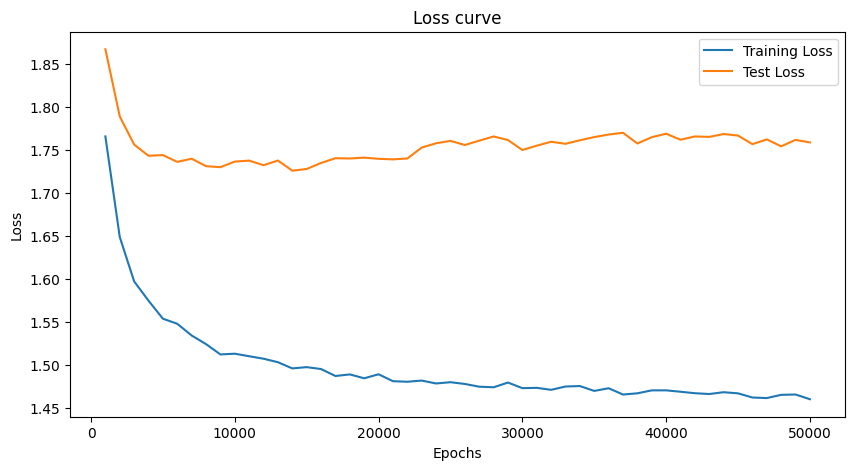

In [9]:
import matplotlib.pyplot as plt

### Visualize loss progression ###
plt.figure(figsize=(10, 5))
plt.plot(epoch_count, train_loss_values, label="Training Loss")
plt.plot(epoch_count, test_loss_values, label="Test Loss")
plt.title("Loss curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [10]:
### Use model ###

def evaluate(model, start='\n', length=1000):
    model.eval()

    hidden = model.init_hidden()
    prime_input = torch.tensor([[char_to_num[c] for c in start]])
    predicted = start

    # Build up hidden state
    for i in range(len(start) - 1):
        with torch.inference_mode():
            _, hidden = model(prime_input[i].to(device), hidden)

    # Generate new sequence
    input = prime_input[-1]
    for i in range(length):
        with torch.inference_mode():
            output, hidden = model(input.to(device), hidden)

        probs = F.softmax(output.detach(), dim=1)
        ix = torch.multinomial(probs, num_samples=1)[0]

        char = num_to_char[ix.item()]
        predicted += char
        input = ix.clone().detach()
    
    return predicted
    
print(evaluate(model))


Hele,
When thy prongules, if me, 'twixt stay thee,
O, are two honour:
But such a loss Bohall dreameting at your a brother, in thy bease, rathee
And in bride
Be answer me are the churk:
What weapiest
The lamb,
This great to nothing begin thee if heaven defiling mine love!' thorry!

First Mustant of all the army fault colen up it, with terves cruactents of them Warwick, Roman. I thought the duke,
And father:
Have you by to ausemance have poss eye strike'l, man!

KING EDWARD IV:
You chare, O,!
3 KING HENRY VI

Off
Is as he strait,
Not use prithted, so intess sition enterful to Hastent, there lives tomes rikethill your packest sinian and solsonged straights in many scatorn answer him starmery fathom like brotherious protegnseemer life woes;
I hopsoove might a lords,
Excefles so.

Mess:
Regrotiest,
To cold, what's in them shall be we.

MERCUTIO:
If hath excofting'd. I far my way,
By an orse? which on, grieven oe gul hither than not train,
Even farewell better speak with thronce thou palsu;